# LDA (Linear Discriminant Analysis) — UCI HAR Veri Seti Üzerinde Uygulama

Bu defter, LDA'yı UCI HAR (Human Activity Recognition) veri setine uygular.
Veri: 561 özellik, 6 aktivite sınıfı.

Konu anlatımı için aynı klasördeki `lda_konu_anlatimi.md` dosyasına bakabilirsiniz.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

plt.rcParams['figure.dpi'] = 110
np.random.seed(42)


## 1. Veriyi Yükleme

In [2]:
DATA_DIR = "../data/UCI HAR Dataset"

X = pd.read_csv(f"{DATA_DIR}/train/X_train.txt", sep=r"\s+", header=None)
y = pd.read_csv(f"{DATA_DIR}/train/y_train.txt", sep=r"\s+", header=None)[0]
activity_labels = pd.read_csv(f"{DATA_DIR}/activity_labels.txt", sep=r"\s+", header=None, index_col=0)[1]
y_named = y.map(activity_labels)

print("X boyutu:", X.shape)
print(y_named.value_counts())


X boyutu: (7352, 561)
0
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


## 2. Ölçekleme (Standardization)

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Ölçeklenmiş veri şekli:", X_scaled.shape)


Ölçeklenmiş veri şekli: (7352, 561)


## 3. LDA ile 2 Boyuta İndirgeme

LDA gözetimli bir yöntemdir, bu yüzden `fit_transform` çağrısına etiketleri (y) de veriyoruz.
6 sınıf olduğu için en fazla 5 bileşen çıkarabiliriz; görselleştirme için ilk 2'sini kullanıyoruz.


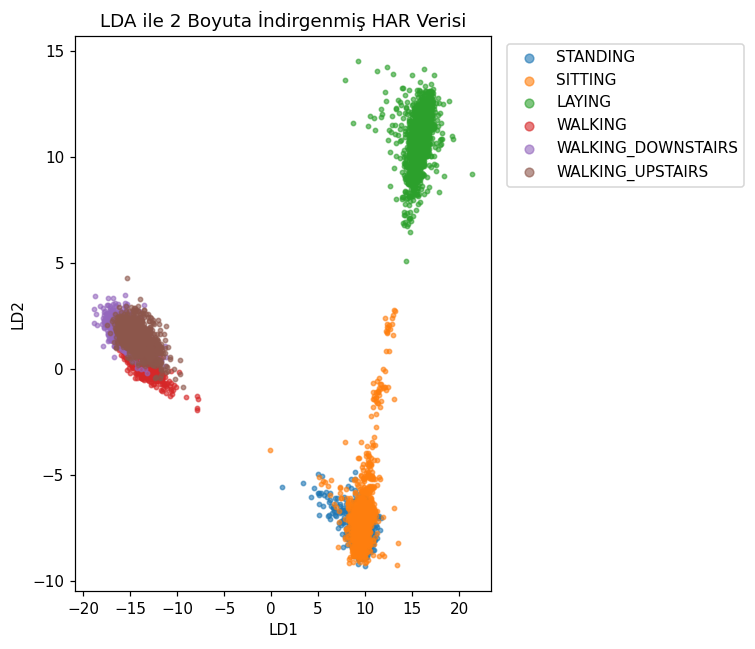

In [4]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

plt.figure(figsize=(7,6))
for label in y_named.unique():
    mask = y_named == label
    plt.scatter(X_lda[mask, 0], X_lda[mask, 1], s=8, alpha=0.6, label=label)
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA ile 2 Boyuta İndirgenmiş HAR Verisi")
plt.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 4. Yorum

LDA, etiket bilgisini kullandığı için sınıfları PCA'dan çok daha net ayırır — hatta çoğu zaman tek başına
2 bileşenle bile sınıflar neredeyse tamamen ayrışır. Bu, LDA'nın sınıflandırma öncesi boyut indirgemede neden
sıkça tercih edildiğini gösterir.
